# ML Project

## Data Modeling

### Ranking Problem (First Problem)

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ndcg_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor

# Load the dataset
file_path = '../dataset_for_modeling/features_for_ranking.csv'
rank_teams = pd.read_csv(file_path)

feature_columns = [
    "player_awards", "net_rating", "off_eff", "def_eff", "home_win_pct",
    "away_win_pct", "reb_dif", "conf_win_pct", "ast_dif", "blk_dif",
    "pf_dif", "coach_awards", "efg_pct", "win_pct", "pts_per_poss",
    "ts_pct", "eff_x_pace", "net_four_factors", "pyth_wins"
]

# Add 'rank' and 'confID' for lagging and grouping
base_columns = feature_columns + ['rank', 'confID']

# Ensure data is sorted by team and year for correct lagging
rank_teams = rank_teams.sort_values(by=['tmID', 'year'])


In [28]:
# Create Lag-1 Features (Last Year's Stats)
lag1_feature_names = [f"{col}_lag1" for col in base_columns]
rank_teams[lag1_feature_names] = rank_teams.groupby('tmID')[base_columns].shift(1)

# Create 3-Year Rolling Avg Features
cols_to_weight = feature_columns + ['rank']
avg3yr_feature_names = [f"{col}_avg3yr_lag" for col in cols_to_weight]

# Define the weighted average function
def weighted_avg(series):
    """
    Calculates a weighted average adapting to available history (1, 2, or 3 years).
    Weights: 0.5 (Last Year), 0.3 (2 Years Ago), 0.2 (3 Years Ago).
    """
    weights = np.array([0.2, 0.3, 0.5])
    
    # Convert series to array to handle NaNs safely
    s = np.array(series)
    mask = ~np.isnan(s)
    
    # If no valid data exists in the window, return NaN
    if not np.any(mask):
        return np.nan
        
    # Adjust weights to the window size and available data
    w = weights[-len(s):]
    valid_s = s[mask]
    valid_w = w[mask]
    
    # Normalize by the sum of valid weights
    return np.sum(valid_s * valid_w) / np.sum(valid_w)

# Calculate rolling average on the lag-1 features
# min_periods=1 ensures we calculate averages even for teams with short history
rolling_avg_features = rank_teams.groupby('tmID')[[f"{col}_lag1" for col in cols_to_weight]] \
                                 .rolling(window=3, min_periods=1) \
                                 .apply(weighted_avg, raw=True)

# Align the rolling average index
rank_teams[avg3yr_feature_names] = rolling_avg_features.reset_index(level=0, drop=True)

# Clean Data
# Only drop rows if Lag-1 data is missing.
# This keeps teams that have Year N-1 data but lack Year N-2 or N-3.
model_df = rank_teams.dropna(subset=lag1_feature_names)

print(f"Original shape: {rank_teams.shape}, Model-ready shape: {model_df.shape}")


Original shape: (142, 65), Model-ready shape: (122, 65)


In [29]:
# The target is always the rank of the CURRENT year
target_col = 'rank'

# Experiment A: Use only last year's stats
features_lag1 = [f"{col}_lag1" for col in feature_columns] + ['rank_lag1']

# Experiment B: Use only the 3-year average stats
features_avg3yr = [f"{col}_avg3yr_lag" for col in feature_columns] + ['rank_avg3yr_lag']

# Experiment C: Use both sets
features_combined = features_lag1 + features_avg3yr

feature_sets = {
    "Lag 1 Only": features_lag1,
    "Avg 3-Year Only": features_avg3yr,
    "Combined": features_combined
}


In [30]:
TEST_YEAR = 10
VALIDATION_YEAR = 9

# Train: All years BEFORE the validation year
train_df = model_df[model_df['year'] < VALIDATION_YEAR] # Years 2-8
y_train = train_df[target_col]

# Validate: Only the validation year
val_df = model_df[model_df['year'] == VALIDATION_YEAR] # Year 9
y_val = val_df[target_col]

# Test: Only the test year
test_df = model_df[model_df['year'] == TEST_YEAR] # Year 10
y_test = test_df[target_col]

print(f"Training observations: {len(train_df)}")
print(f"Validation observations: {len(val_df)}")
print(f"Test observations: {len(test_df)}")


Training observations: 96
Validation observations: 13
Test observations: 13


In [31]:
# Get the baseline prediction (last year's rank)
y_pred_baseline = val_df['rank_lag1']

y_pred_baseline.head()

# Evaluate baseline on the Validation set
mae_baseline = mean_absolute_error(y_val, y_pred_baseline)
spearman_baseline, _ = spearmanr(y_val, y_pred_baseline)

print("--- Baseline Model (on Validation Set) ---")
print(f"  MAE: {mae_baseline:.4f}")
print(f"  Spearman Rank: {spearman_baseline:.4f}")


--- Baseline Model (on Validation Set) ---
  MAE: 1.5385
  Spearman Rank: 0.4008


In [32]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Ridge Regression': Ridge(),
    'SVR':SVR(),
    'AdaBoost':AdaBoostRegressor(random_state=42)
}

results = []

for fs_name, fs_cols in feature_sets.items():
    print(f"\n--- Testing Feature Set: {fs_name} ---")
    
    # Define X data based on the current feature set
    X_train = train_df[fs_cols]
    X_val = val_df[fs_cols]

    # Scale data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    for name, model in models.items():
        # Fit model
        model.fit(X_train_scaled, y_train)
        y_pred_val = model.predict(X_val_scaled)
        
        # Evaluate model
        mae = mean_absolute_error(y_val, y_pred_val)
        spearman_corr, _ = spearmanr(y_val, y_pred_val)
        
        print(f"  Model: {name}")
        print(f"    MAE: {mae:.4f} (Baseline: {mae_baseline:.4f})")
        print(f"    Spearman: {spearman_corr:.4f} (Baseline: {spearman_baseline:.4f})")
        
        results.append((fs_name, name, mae, spearman_corr))

best_result = min(results, key=lambda item: item[2])
best_fs_name, best_model_name, best_mae, best_spearman = best_result

print(f"\n--- Best Model from Validation (based on MAE) ---")
print(f"  Feature Set: {best_fs_name}")
print(f"  Model: {best_model_name}")
print(f"  Spearman: {best_spearman:.4f}")



--- Testing Feature Set: Lag 1 Only ---
  Model: Linear Regression
    MAE: 2.0144 (Baseline: 1.5385)
    Spearman: 0.0277 (Baseline: 0.4008)
  Model: Random Forest
    MAE: 1.6900 (Baseline: 1.5385)
    Spearman: 0.1551 (Baseline: 0.4008)
  Model: Gradient Boosting
    MAE: 1.9915 (Baseline: 1.5385)
    Spearman: 0.1108 (Baseline: 0.4008)
  Model: Ridge Regression
    MAE: 1.9424 (Baseline: 1.5385)
    Spearman: 0.0416 (Baseline: 0.4008)
  Model: SVR
    MAE: 1.6298 (Baseline: 1.5385)
    Spearman: 0.2299 (Baseline: 0.4008)
  Model: AdaBoost
    MAE: 1.8926 (Baseline: 1.5385)
    Spearman: 0.0360 (Baseline: 0.4008)

--- Testing Feature Set: Avg 3-Year Only ---
  Model: Linear Regression
    MAE: 1.7001 (Baseline: 1.5385)
    Spearman: 0.0277 (Baseline: 0.4008)
  Model: Random Forest
    MAE: 1.7492 (Baseline: 1.5385)
    Spearman: -0.0526 (Baseline: 0.4008)
  Model: Gradient Boosting
    MAE: 1.7169 (Baseline: 1.5385)
    Spearman: 0.0693 (Baseline: 0.4008)
  Model: Ridge Regression


In [33]:
# Prepare Data (Train + Validation combined for Cross-Validation)
# We use the best feature set found in the previous step
best_features = feature_sets[best_fs_name]

X_train_full = pd.concat([train_df[best_features], val_df[best_features]])
y_train_full = pd.concat([y_train, y_val])

# Define Models and their Hyperparameter Grids
model_configs = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300, 500],
            "model__max_depth": [5, 10, 20, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ['sqrt', 'log2', None]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 300, 500, 1000],
            "model__learning_rate": [0.005, 0.01, 0.05, 0.1],
            "model__max_depth": [3, 4, 5],
            "model__subsample": [0.7, 0.8, 0.9, 1.0]
        }
    },
    "Ridge Regression": {
        "model": Ridge(),
        "params": {
            "model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            "model__C": [0.1, 1, 10, 100, 1000],
            "model__kernel": ['linear', 'rbf', 'poly'],
            "model__epsilon": [0.01, 0.1, 0.2, 0.5],
            "model__gamma": ['scale', 'auto', 0.1, 0.01]
        }
    },
    "AdaBoost": {
        "model": AdaBoostRegressor(random_state=42),
        "params": {
            "model__n_estimators": [50, 100, 300, 500],
            "model__learning_rate": [0.001, 0.01, 0.1, 1.0],
            "model__loss": ['linear', 'square', 'exponential']
        }
    },
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {
            "model__fit_intercept": [True, False]
        }
    }
}

# Run Systematic Grid Search for all Models
results = []
best_overall_model = None
best_overall_score = -float("inf") # Since we use neg_MAE, closer to 0 is better

print(f"--- Starting Extensive Grid Search on {len(model_configs)} Models ---")

for name, config in model_configs.items():
    print(f"\nTraining {name}...")
    
    # Create a Pipeline: Scaler -> Model
    # Scaling is crucial for SVR/Ridge, and harmless for Trees
    pipeline = Pipeline([
        ('scaler', StandardScaler()), 
        ('model', config['model'])
    ])
    
    # Setup Grid Search
    grid = GridSearchCV(
        pipeline, 
        config['params'], 
        cv=3, # 3-Fold Cross Validation
        scoring='neg_mean_absolute_error', 
        n_jobs=-1,
        verbose=1
    )
    
    # Train
    grid.fit(X_train_full, y_train_full)
    
    # Get results (Convert neg_MAE to positive MAE for readability)
    best_mae = -grid.best_score_
    
    print(f"  > Best MAE: {best_mae:.4f}")
    print(f"  > Best Params: {grid.best_params_}")
    
    results.append({
        "Model": name,
        "MAE": best_mae,
        "Best_Estimator": grid.best_estimator_,
        "Best_Params": grid.best_params_
    })
    
    # Track the global winner
    if grid.best_score_ > best_overall_score:
        best_overall_score = grid.best_score_
        best_overall_model = grid.best_estimator_
        best_model_name = name

# Summary
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='MAE', ascending=True)

print("\n--- Model Classification Table ---")
print(results_df[['Model', 'MAE', 'Best_Params']].to_string(index=False))

print("\n==================================================")
print(f"Best Model in Training: {best_model_name} with MAE: {-best_overall_score:.4f}")
print("==================================================")

# Set final_model to the winner
final_model = best_overall_model


--- Starting Extensive Grid Search on 6 Models ---

Training Random Forest...
Fitting 3 folds for each of 432 candidates, totalling 1296 fits


KeyboardInterrupt: 


--- Baseline Model Evaluation (on Test Set: Year 10) ---
  MAE: 2.4615
  Spearman Rank: -0.1299


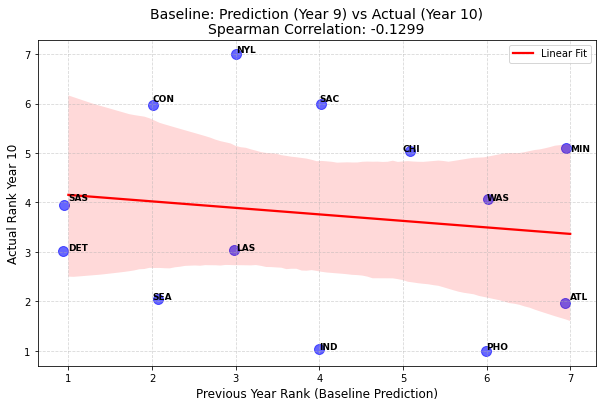

In [ ]:
# --- Baseline for the final test set
y_pred_baseline_test = test_df['rank_lag1']
mae_baseline_test = mean_absolute_error(y_test, y_pred_baseline_test)
spearman_baseline_test, _ = spearmanr(y_test, y_pred_baseline_test)

print("\n--- Baseline Model Evaluation (on Test Set: Year 10) ---")
print(f"  MAE: {mae_baseline_test:.4f}")
print(f"  Spearman Rank: {spearman_baseline_test:.4f}")

plt.figure(figsize=(10, 6))

# Create Plot (Scatter + Regression Line)
# x_jitter helps to see overlapping points (e.g., two teams that were rank 1)
sns.regplot(x='rank_lag1', y='rank', data=test_df, 
            x_jitter=0.1, y_jitter=0.1, 
            scatter_kws={'s': 100, 'alpha': 0.6, 'color': 'blue'},
            line_kws={'color': 'red', 'label': 'Linear Fit'})

# Add Labels (Team Name) to each point
for i, row in test_df.iterrows():
    plt.text(row['rank_lag1'], row['rank'], row['tmID'], 
             fontsize=9, ha='left', va='bottom', fontweight='bold')

plt.title(f"Baseline: Prediction (Year 9) vs Actual (Year 10)\nSpearman Correlation: {spearman_baseline_test:.4f}", fontsize=14)
plt.xlabel("Previous Year Rank (Baseline Prediction)", fontsize=12)
plt.ylabel("Actual Rank Year 10", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


--- Evaluating all optimized models on the Test Set (Year 10) ---

--- Final Showdown: Validation vs Test Performance ---
            Model  Validation MAE  Test MAE (Year 10)  Test RMSE (Year 10)  Test Spearman  Generalization Gap
Gradient Boosting        1.662585            1.565960             1.949131       0.340732           -0.096625
    Random Forest        1.616001            1.621726             2.013023       0.204993            0.005726
         AdaBoost        1.636795            1.667556             2.014118       0.193913            0.030761
 Ridge Regression        1.542538            1.692867             2.178466       0.152360            0.150329
              SVR        1.512323            1.875235             2.450020       0.088646            0.362911
Linear Regression        2.176105            2.362403             3.035991       0.049863            0.186298


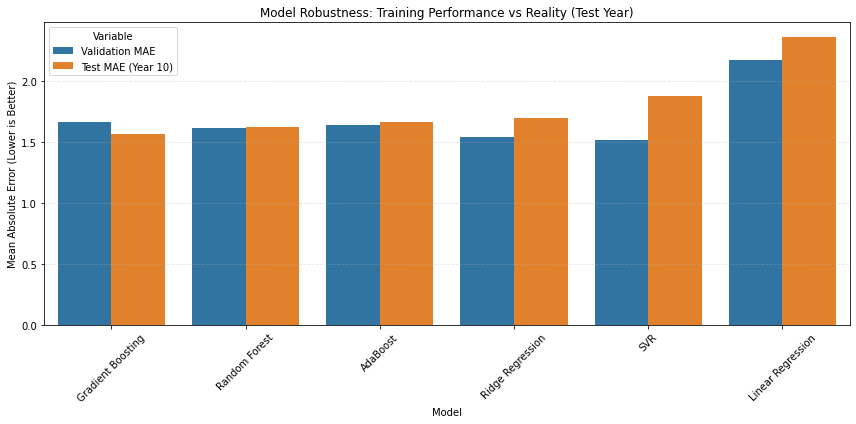


Best Model in Testing (Year 10): Gradient Boosting


In [ ]:
# Prepare Test Data
X_test = test_df[best_features]
y_test = test_df[target_col]

print(f"--- Evaluating all optimized models on the Test Set (Year 10) ---")

final_comparison = []

# Iterate through the results of the Grid Search
for index, row in results_df.iterrows():
    model_name = row['Model']
    trained_model = row['Best_Estimator']
    val_mae = row['MAE']
    
    # Predict on Test Set (Year 10)
    y_pred_test = trained_model.predict(X_test)
    
    # Calculate Test Metrics
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_spearman, _ = spearmanr(y_test, y_pred_test)
    
    final_comparison.append({
        "Model": model_name,
        "Validation MAE": val_mae,
        "Test MAE (Year 10)": test_mae,
        "Test RMSE (Year 10)": test_rmse,
        "Test Spearman": test_spearman,
        "Generalization Gap": test_mae - val_mae,
        "Best_Estimator": trained_model
    })

# Create DataFrame for comparison
comparison_df = pd.DataFrame(final_comparison)
comparison_df = comparison_df.sort_values(by='Test MAE (Year 10)', ascending=True)

display_cols = ["Model", "Validation MAE", "Test MAE (Year 10)", "Test RMSE (Year 10)", "Test Spearman", "Generalization Gap"]

print("\n--- Final Showdown: Validation vs Test Performance ---")
print(comparison_df[display_cols].to_string(index=False))

# Plot Comparison
plt.figure(figsize=(12, 6))
tidy = comparison_df.melt(id_vars='Model').rename(columns=str.title)
tidy = tidy[tidy['Variable'].isin(['Validation MAE', 'Test MAE (Year 10)'])]

sns.barplot(x='Model', y='Value', hue='Variable', data=tidy)
plt.title("Model Robustness: Training Performance vs Reality (Test Year)")
plt.ylabel("Mean Absolute Error (Lower is Better)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

best_test_model_row = comparison_df.iloc[0]
final_model_name = best_test_model_row['Model']
final_model = best_test_model_row['Best_Estimator']
mae_final = best_test_model_row['Test MAE (Year 10)']

print(f"\nBest Model in Testing (Year 10): {best_test_model_row['Model']}")


In [ ]:
# Generate Final Predictions with the Best Model
y_pred_final = final_model.predict(X_test)

# Create the final results DataFrame
final_results_df = test_df[['tmID', 'confID', 'year', 'rank', 'rank_lag1']].copy()
final_results_df.rename(columns={'rank': 'actual_rank', 'rank_lag1': 'baseline_rank'}, inplace=True)
final_results_df['predicted_rank_raw'] = y_pred_final

# Rank the model's raw predictions to get a 1-N ranking
final_results_df['predicted_rank_model'] = final_results_df.groupby('confID')['predicted_rank_raw'] \
                                                          .rank(method='first', ascending=True) \
                                                          .astype(int)

# Sort for easy viewing
final_results_df = final_results_df.sort_values(by=['confID', 'actual_rank'])

print("\n--- Final Predicted vs. Actual Rankings (Year 10) ---")
print(final_results_df[['confID', 'tmID', 'actual_rank', 'baseline_rank', 'predicted_rank_model']].to_string(index=False))

improvement_pct = ((mae_baseline_test - mae_final) / mae_baseline_test) * 100

print(f"\n--- Performance Comparison ---")
print(f"Baseline Error (Previous Year Rank): {mae_baseline_test:.4f}")
print(f"Model Error (With Custom Features): {mae_final:.4f}")
print(f"--------------------------------------------------")
print(f"TOTAL IMPROVEMENT: {improvement_pct:.2f}%")



--- Final Predicted vs. Actual Rankings (Year 10) ---
confID tmID  actual_rank  baseline_rank  predicted_rank_model
    EA  IND            1            4.0                     1
    EA  ATL            2            7.0                     7
    EA  DET            3            1.0                     2
    EA  WAS            4            6.0                     6
    EA  CHI            5            5.0                     5
    EA  CON            6            2.0                     3
    EA  NYL            7            3.0                     4
    WE  PHO            1            6.0                     3
    WE  SEA            2            2.0                     1
    WE  LAS            3            3.0                     2
    WE  SAS            4            1.0                     5
    WE  MIN            5            7.0                     6
    WE  SAC            6            4.0                     4

--- Performance Comparison ---
Baseline Error (Previous Year Rank): 2.4615
M

In [ ]:
# Function to calculate NDCG
def calculate_ndcg(df):
    ndcg_values = []
    
    for conf in df['confID'].unique():
        conf_data = df[df['confID'] == conf].copy()
        
        # Transform Rank into Relevance (Rank 1 = High Relevance)
        # Example: If 6 teams, Rank 1 gets score 6, Rank 6 gets score 1
        max_rank = conf_data['actual_rank'].max()
        
        # Create relevance arrays (1 sample, N items)
        true_relevance = [((max_rank + 1) - conf_data['actual_rank'].values)]
        predicted_scores = [((max_rank + 1) - conf_data['predicted_rank_model'].values)]
        
        # Calculate NDCG
        score = ndcg_score(true_relevance, predicted_scores)
        ndcg_values.append(score)
        
    return np.mean(ndcg_values)

# Calculate and Print
avg_ndcg = calculate_ndcg(final_results_df)
print(f"NDCG Score: {avg_ndcg:.4f} (Closer to 1.0 is better)")


NDCG Score: 0.9421 (Closer to 1.0 is better)


In [ ]:
def calculate_business_metrics(df):
    precisions = []
    
    print(f"\n--- Business Metrics Analysis (Playoff Precision) ---")

    for conf in df['confID'].unique():
        conf_data = df[df['confID'] == conf]
        
        # --- Precision@4 (Playoff Accuracy) ---
        # Identify the actual teams that made Top 4
        actual_playoff_teams = set(conf_data[conf_data['actual_rank'] <= 4]['tmID'])
        
        # Identify the teams the MODEL predicted for Top 4
        predicted_playoff_teams = set(conf_data[conf_data['predicted_rank_model'] <= 4]['tmID'])
        
        # How many did we get right?
        correct_hits = len(actual_playoff_teams.intersection(predicted_playoff_teams))
        precision = correct_hits / 4.0 # Since 4 teams qualify
        precisions.append(precision)
        
        print(f"Conference {conf}: Playoff Precision = {precision*100:.0f}% ({correct_hits}/4)")
        
    avg_precision = np.mean(precisions)
    
    print(f"---------------------------------")
    print(f"AVG Playoff Precision: {avg_precision*100:.1f}%")

# Run the function
calculate_business_metrics(final_results_df)



--- Business Metrics Analysis (Playoff Precision) ---
Conference EA: Playoff Precision = 50% (2/4)
Conference WE: Playoff Precision = 75% (3/4)
---------------------------------
AVG Playoff Precision: 62.5%


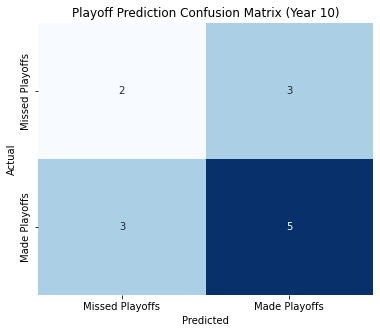

In [ ]:
# Create Binary Columns for Playoffs (Top 4 = Yes, >4 = No)
final_results_df['Actual_Playoff'] = final_results_df['actual_rank'] <= 4
final_results_df['Predicted_Playoff'] = final_results_df['predicted_rank_model'] <= 4

# Generate Confusion Matrix
cm = confusion_matrix(final_results_df['Actual_Playoff'], final_results_df['Predicted_Playoff'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Missed Playoffs', 'Made Playoffs'],
            yticklabels=['Missed Playoffs', 'Made Playoffs'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Playoff Prediction Confusion Matrix (Year 10)')
plt.show()


### Player Awards Problem (Third Problem)

#### Most Improved Player Award

##### Data Analyses

/tmp/ipykernel_7583/3478013054.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='viridis')
/tmp/ipykernel_7583/3478013054.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='Set2')
/tmp/ipykernel_7583/3478013054.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='Set2')
/tmp/ipykernel_7583/3478013054.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

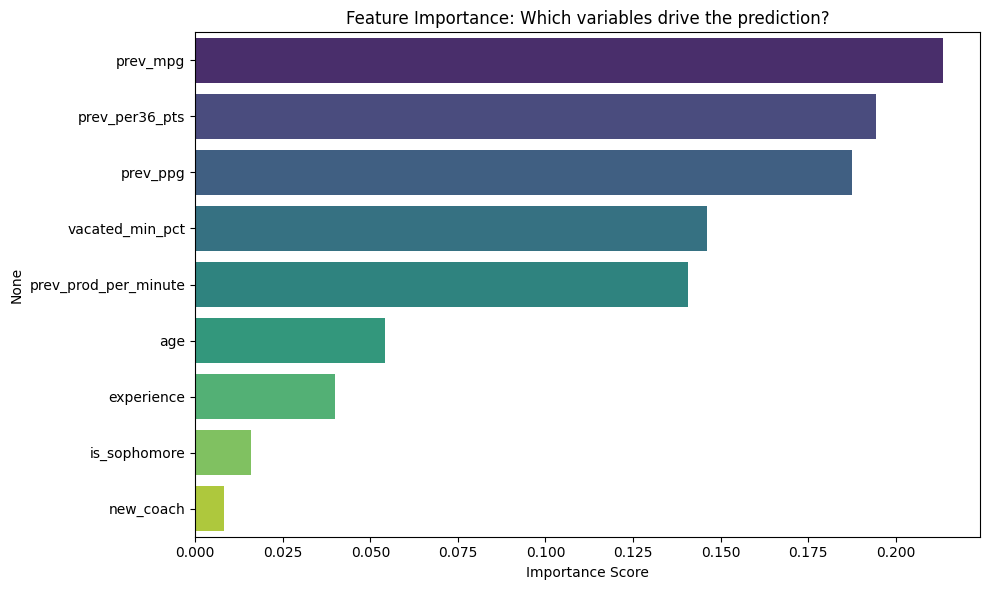

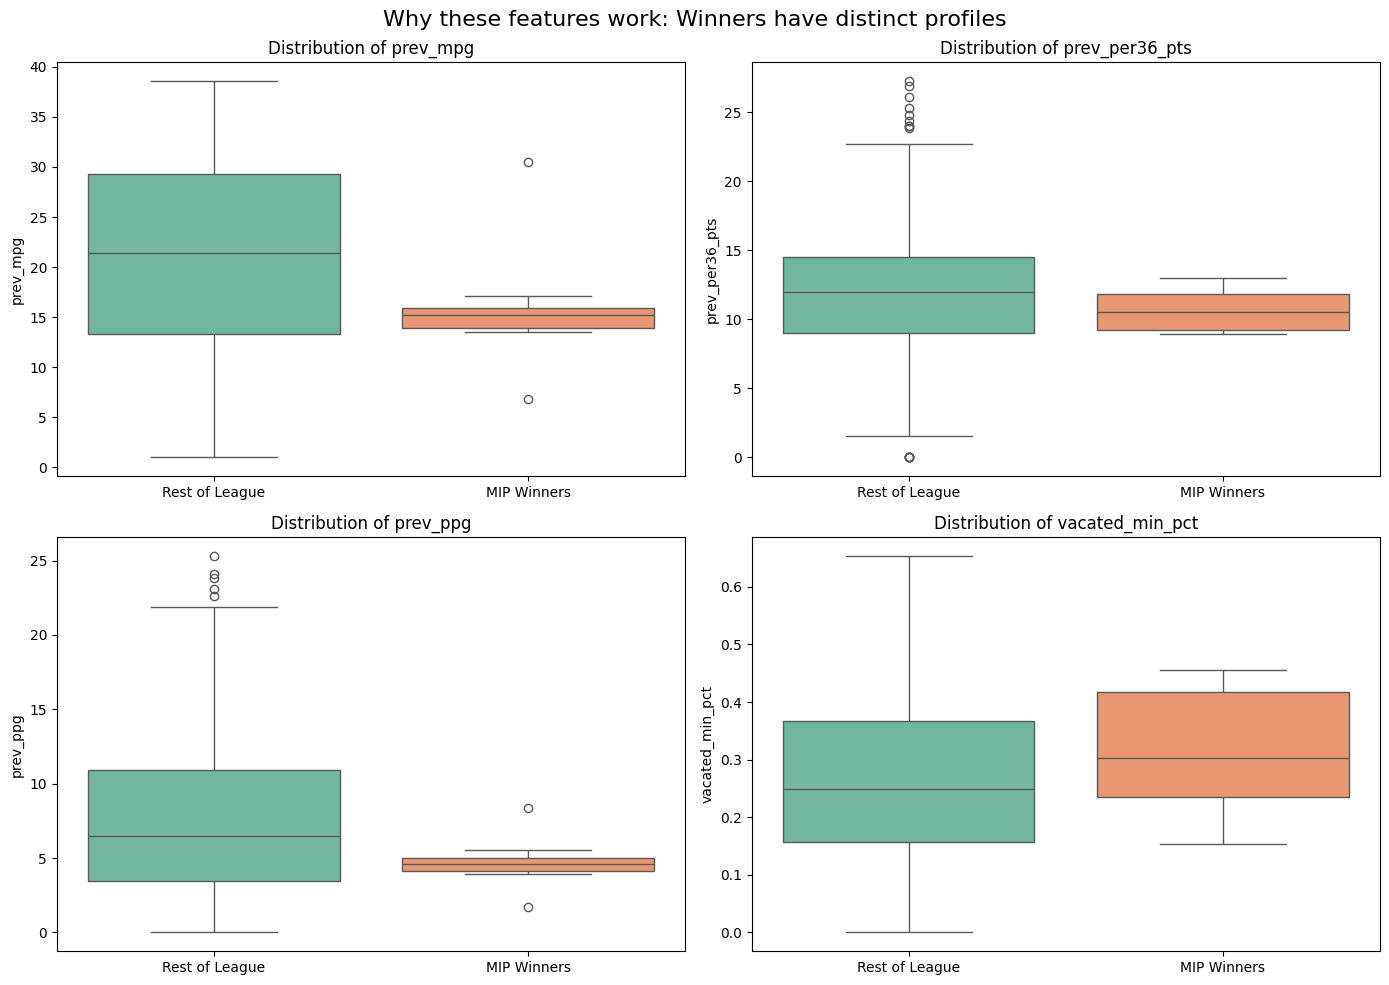

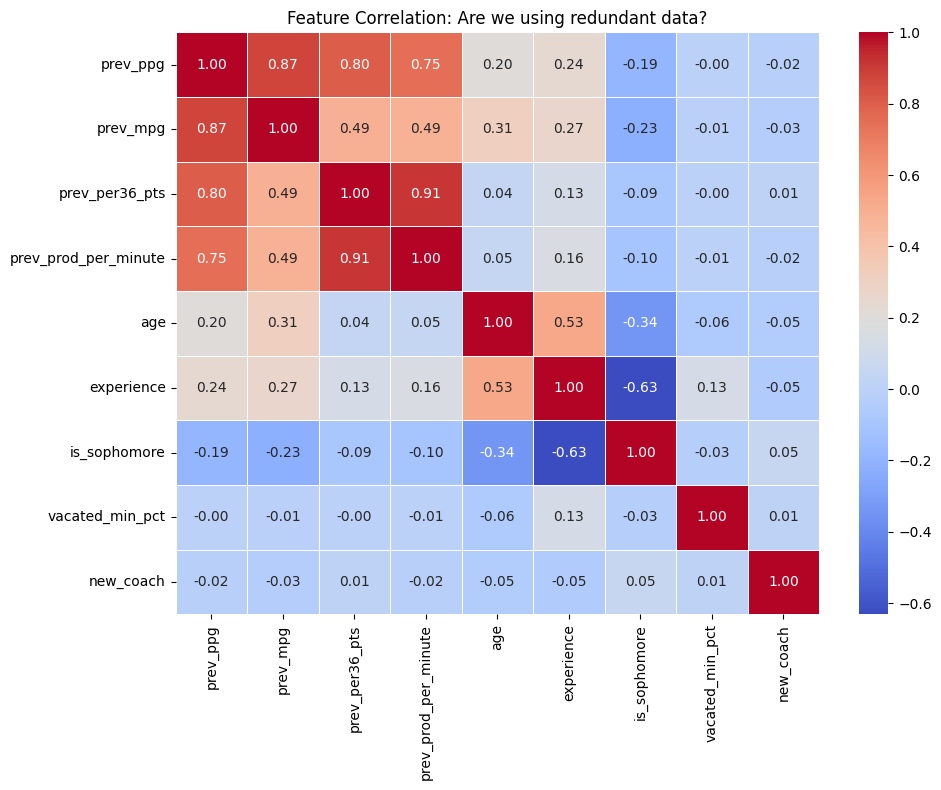

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

df_players_teams = pd.read_csv('../dataset_cleaned/players_teams.csv')
df_awards = pd.read_csv('../dataset_cleaned/awards_players.csv')
df_players = pd.read_csv('../dataset_cleaned/players.csv')
df_teams = pd.read_csv('../dataset_cleaned/teams.csv')
df_coaches = pd.read_csv('../dataset_cleaned/coaches.csv')

# --- Feature Engineering ---

# Demographics
df_players['birth_year'] = pd.to_datetime(df_players['birthDate'], errors='coerce').dt.year
df_players_teams = pd.merge(df_players_teams, df_players[['bioID', 'birth_year']], left_on='playerID', right_on='bioID', how='left')
df_players_teams.sort_values(['playerID', 'year'], inplace=True)
df_players_teams['experience'] = df_players_teams.groupby('playerID').cumcount()
df_players_teams['is_sophomore'] = (df_players_teams['experience'] == 1).astype(int)
df_players_teams['age'] = (1996 + df_players_teams['year']) - df_players_teams['birth_year']
df_players_teams['age'] = df_players_teams['age'].fillna(25)

# Team Context (Vacated Minutes)
rosters = df_players_teams.groupby(['year', 'tmID', 'playerID'])['minutes'].sum().reset_index()
vacated_list = []
years = sorted(df_players_teams['year'].unique())
teams = df_players_teams['tmID'].unique()

for yr in years:
    if yr == 1: continue
    prev = yr - 1
    for tm in teams:
        ros_prev = rosters[(rosters['year'] == prev) & (rosters['tmID'] == tm)]
        ros_curr = rosters[(rosters['year'] == yr) & (rosters['tmID'] == tm)]
        
        if ros_prev.empty: 
            vacated_list.append({'year': yr, 'tmID': tm, 'vacated_min_pct': 0})
            continue
        
        left = set(ros_prev['playerID']) - set(ros_curr['playerID'])
        vacated = ros_prev[ros_prev['playerID'].isin(left)]['minutes'].sum()
        total = ros_prev['minutes'].sum()
        ratio = vacated / total if total > 0 else 0
        vacated_list.append({'year': yr, 'tmID': tm, 'vacated_min_pct': ratio})

df_vacated = pd.DataFrame(vacated_list)

# Aggregation
stats = df_players_teams.groupby(['playerID', 'year']).agg({
    'GP': 'sum', 'minutes': 'sum', 'points': 'sum', 'rebounds': 'sum', 'assists': 'sum',
    'tmID': 'first', 'experience': 'first', 'is_sophomore': 'max', 'age': 'max'
}).reset_index()

# Basic & Advanced Stats
stats['ppg'] = stats['points'] / stats['GP']
stats['mpg'] = stats['minutes'] / stats['GP']
# Per 36 Minutes
stats['per36_pts'] = (stats['points'] / stats['minutes'].replace(0, 1)) * 36
# Production Per Minute
stats['prod_per_minute'] = (stats['points'] + stats['rebounds'] + stats['assists']) / stats['minutes'].replace(0, 1)

# Build Dataset (Lagged Features)
data_rows = []
for yr in years:
    if yr == 1: continue
    curr = stats[stats['year'] == yr][['playerID', 'year', 'tmID', 'age', 'experience', 'is_sophomore']].copy()
    prev = stats[stats['year'] == yr - 1].copy()
    prev.columns = [f'prev_{c}' if c != 'playerID' else 'playerID' for c in prev.columns]
    merged = pd.merge(curr, prev, on='playerID', how='inner')
    data_rows.append(merged)

df_final = pd.concat(data_rows, ignore_index=True)
df_final = pd.merge(df_final, df_vacated, on=['year', 'tmID'], how='left')

# Coaching Change
coaches = df_coaches[['year', 'tmID', 'coachID']].drop_duplicates(subset=['year', 'tmID'])
df_final = pd.merge(df_final, coaches, on=['year', 'tmID'], how='left')
df_final.rename(columns={'coachID': 'curr_coach'}, inplace=True)
coaches_prev = coaches.copy()
coaches_prev['next_year'] = coaches_prev['year'] + 1
df_final = pd.merge(df_final, coaches_prev[['next_year', 'tmID', 'coachID']], 
                    left_on=['year', 'tmID'], right_on=['next_year', 'tmID'], how='left')
df_final.rename(columns={'coachID': 'prev_coach'}, inplace=True)
df_final['new_coach'] = (df_final['curr_coach'] != df_final['prev_coach']).astype(int)

# Target
mip_winners = df_awards[df_awards['award'] == 'Most Improved Player']
winners_map = mip_winners[['playerID', 'year']].copy()
winners_map['won'] = 1
df_final = pd.merge(df_final, winners_map, on=['playerID', 'year'], how='left')
df_final['won'] = df_final['won'].fillna(0).astype(int)

features = [
    'prev_ppg', 'prev_mpg', 
    'prev_per36_pts', 'prev_prod_per_minute',
    'age', 'experience', 'is_sophomore',     
    'vacated_min_pct', 'new_coach'
]
df_final[features] = df_final[features].fillna(0)

# 1. Feature Importance (Model Based)
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)
rf.fit(df_final[features], df_final['won'])

plt.figure(figsize=(10, 6))
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=imp.values, y=imp.index, palette='viridis')
plt.title('Feature Importance: Which variables drive the prediction?')
plt.xlabel('Importance Score')
plt.tight_layout()

# 2. Winners vs Non-Winners Distribution (Boxplots)
# Select top 4 features for detailed view
top_features = imp.index[:4].tolist()
df_plot = df_final.copy()
df_plot['Status'] = df_plot['won'].map({0: 'Rest of League', 1: 'MIP Winners'})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel('')

plt.suptitle('Why these features work: Winners have distinct profiles', fontsize=16)
plt.tight_layout()

# 3. Correlation Heatmap (Redundancy Check)
plt.figure(figsize=(10, 8))
corr = df_final[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation: Are we using redundant data?')
plt.tight_layout()


##### Feature Engineering and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

df_players_teams = pd.read_csv('../dataset_cleaned/players_teams.csv')
df_coaches = pd.read_csv('../dataset_cleaned/coaches.csv')
df_awards = pd.read_csv('../dataset_cleaned/awards_players.csv')
df_teams = pd.read_csv('../dataset_cleaned/teams.csv')
df_players = pd.read_csv('../dataset_cleaned/players.csv')


# Experience, Age & Sophomore Flag
df_players_teams.sort_values(['playerID', 'year'], inplace=True)
df_players_teams['experience'] = df_players_teams.groupby('playerID').cumcount()

df_players_teams['is_sophomore'] = (df_players_teams['experience'] == 1).astype(int)

# Age Calculation
df_players['birth_year'] = pd.to_datetime(df_players['birthDate'], errors='coerce').dt.year
df_merged = pd.merge(df_players_teams, df_players[['bioID', 'birth_year']], left_on='playerID', right_on='bioID', how='left')
df_merged['age'] = (1996 + df_merged['year']) - df_merged['birth_year']
df_merged['age'] = df_merged['age'].fillna(25)

# Most Improved Players often win in their second year (the "Sophomore Surge"). This explicitly flags those candidates

#+ Team Context (Vacated Minutes)
rosters = df_merged.groupby(['year', 'tmID', 'playerID'])['minutes'].sum().reset_index()
vacated_list = []
years = sorted(df_merged['year'].unique())
teams = df_merged['tmID'].unique()

for yr in years:
    if yr == 1: continue
    prev = yr - 1
    for tm in teams:
        ros_prev = rosters[(rosters['year'] == prev) & (rosters['tmID'] == tm)]
        ros_curr = rosters[(rosters['year'] == yr) & (rosters['tmID'] == tm)]
        
        if ros_prev.empty: continue
        
        left = set(ros_prev['playerID']) - set(ros_curr['playerID'])
        vacated = ros_prev[ros_prev['playerID'].isin(left)]['minutes'].sum()
        total = ros_prev['minutes'].sum()
        
        ratio = vacated / total if total > 0 else 0
        vacated_list.append({'year': yr, 'tmID': tm, 'vacated_min_pct': ratio})

df_vacated = pd.DataFrame(vacated_list)

# This calculates the total minutes that, because of players who left the team, are available to ge filled by other players

# Team Performance 
df_teams['win_pct'] = df_teams['won'] / (df_teams['won'] + df_teams['lost'])
df_teams_prev = df_teams[['year', 'tmID', 'win_pct']].copy()
df_teams_prev['next_year'] = df_teams_prev['year'] + 1
df_teams_prev.rename(columns={'win_pct': 'prev_team_win_pct'}, inplace=True)


##### Features Preparation

In [ ]:
stats = df_merged.groupby(['playerID', 'year']).agg({
    'points': 'sum', 
    'rebounds': 'sum', 
    'assists': 'sum', 
    'minutes': 'sum', 
    'GP': 'sum', 
    'tmID': 'first', 
    'experience': 'first', 
    'is_sophomore': 'max', 
    'age': 'max'
}).reset_index()

# Basic Per Game
stats['ppg'] = stats['points'] / stats['GP']
stats['mpg'] = stats['minutes'] / stats['GP']

# Advanced: Per 36 Minutes (Normalizes for playing time)
# Avoid division by zero
stats['per36_pts'] = (stats['points'] / stats['minutes'].replace(0, 1)) * 36
stats['per36_reb'] = (stats['rebounds'] / stats['minutes'].replace(0, 1)) * 36

# Advanced: Efficiency Metric (Simple PER approximation per minute)
stats['prod_per_minute'] = (stats['points'] + stats['rebounds'] + stats['assists']) / stats['minutes'].replace(0, 1)

data = []
for yr in years:
    if yr == 1: continue
    curr = stats[stats['year'] == yr][['playerID', 'year', 'tmID', 'age', 'experience', 'is_sophomore']].copy()
    
    # We want Previous Year's Stats
    prev = stats[stats['year'] == yr - 1].copy()
    # Rename columns
    prev.columns = [f'prev_{c}' if c != 'playerID' else 'playerID' for c in prev.columns]
    
    merged = pd.merge(curr, prev, on='playerID', how='inner')
    merged['year'] = yr
    data.append(merged)

df_final = pd.concat(data)

# Join Context
df_final = pd.merge(df_final, df_vacated, on=['year', 'tmID'], how='left')
df_final = pd.merge(df_final, df_teams_prev[['next_year', 'tmID', 'prev_team_win_pct']], 
                    left_on=['year', 'tmID'], right_on=['next_year', 'tmID'], how='left')

# Coaching Change
coaches = df_coaches[['year', 'tmID', 'coachID']].drop_duplicates(subset=['year', 'tmID'])
df_final = pd.merge(df_final, coaches, on=['year', 'tmID'], how='left')
df_final.rename(columns={'coachID': 'curr_coach'}, inplace=True)

coaches_prev = coaches.copy()
coaches_prev['next_year'] = coaches_prev['year'] + 1
df_final = pd.merge(df_final, coaches_prev[['next_year', 'tmID', 'coachID']], 
                    left_on=['year', 'tmID'], right_on=['next_year', 'tmID'], how='left')
df_final.rename(columns={'coachID': 'prev_coach'}, inplace=True)

# New Coach new opportunities for bench players
df_final['new_coach'] = (df_final['curr_coach'] != df_final['prev_coach']).astype(int)

# Filter Past Winners
# Winner from year 9 cannot win again in year 10
mip_winners = df_awards[df_awards['award'] == 'Most Improved Player']
df_final = pd.merge(df_final, mip_winners[['playerID', 'year']], on='playerID', how='left', suffixes=('', '_won_yr'))
df_final['past_winner'] = (df_final['year_won_yr'].notna()) & (df_final['year_won_yr'] < df_final['year'])
df_final = df_final[~df_final['past_winner']].copy()

##### Model Training and Evaluation


>>> Top 5 Predictions Year 10:
        playerID      prob  prev_ppg  prev_per36_pts  vacated_min_pct
1082  gardike01w  0.195166  4.029412        9.133333         0.187741
1106  langhcr01w  0.140337  4.823529       11.160681         0.367033
1100  johnste01w  0.109527  4.173913        8.793893         0.338412
1124  mitchle01w  0.096493  3.852941        9.104247         0.150268
1129  newtoch01w  0.087943  4.500000       10.717557         0.207914


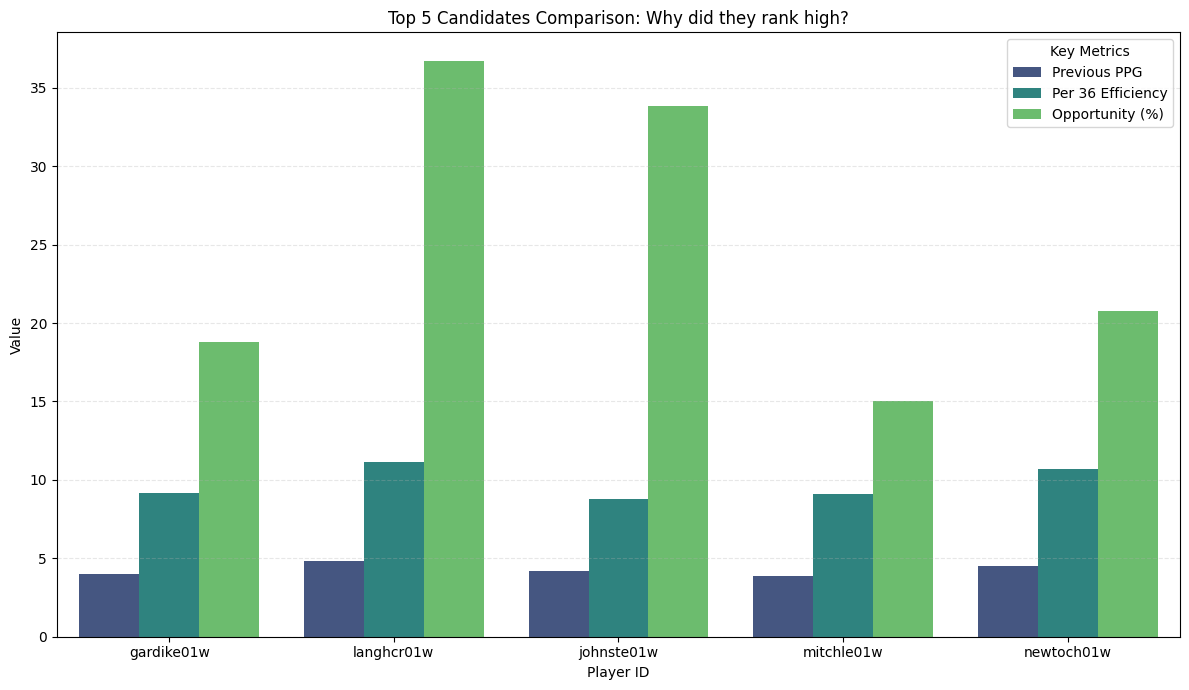

In [ ]:
# New Feature Set includes Per36 and Production Per Minute
features = [
    'prev_ppg', 'prev_mpg', 
    'prev_per36_pts', 'prev_prod_per_minute',
    'age', 'experience', 'is_sophomore',     
    'vacated_min_pct', 'new_coach'
]

df_final[features] = df_final[features].fillna(0)

train = df_final[df_final['year'] < 10]
test = df_final[df_final['year'] == 10]

# Target: Did they win THIS year?
current_winners = mip_winners[['playerID', 'year']].copy()
current_winners['won'] = 1
train = pd.merge(train, current_winners[['playerID', 'year', 'won']], on=['playerID', 'year'], how='left')
train['won'] = train['won'].fillna(0)

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, max_depth=10)
rf.fit(train[features], train['won'])

test = test.copy()
test['prob'] = rf.predict_proba(test[features])[:, 1]

# Get Top 5 Predictions
top5 = test.sort_values('prob', ascending=False).head(5)
print("\n>>> Top 5 Predictions Year 10:")
print(top5[['playerID', 'prob', 'prev_ppg', 'prev_per36_pts', 'vacated_min_pct']])

# Prepare data for plotting
plot_data = top5[['playerID', 'prev_ppg', 'prev_per36_pts', 'vacated_min_pct']].copy()
# Scale vacated_min_pct to be visible alongside PPG (multiply by 100 for percentage)
plot_data['vacated_pct_scaled'] = plot_data['vacated_min_pct'] * 100

# Melt for grouped bar chart
df_melted = plot_data.melt(id_vars='playerID', 
                           value_vars=['prev_ppg', 'prev_per36_pts', 'vacated_pct_scaled'],
                           var_name='Metric', value_name='Value')

# Rename metrics for cleaner legend
metric_labels = {
    'prev_ppg': 'Previous PPG',
    'prev_per36_pts': 'Per 36 Efficiency',
    'vacated_pct_scaled': 'Opportunity (%)'
}
df_melted['Metric'] = df_melted['Metric'].map(metric_labels)

# Plot
plt.figure(figsize=(12, 7))
sns.barplot(x='playerID', y='Value', hue='Metric', data=df_melted, palette='viridis')

plt.title('Top 5 Candidates Comparison: Why did they rank high?')
plt.ylabel('Value')
plt.xlabel('Player ID')
plt.legend(title='Key Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()


#### Kim Perrot Sportsmanship Award

In [108]:
import pandas as pd
import numpy as np

# Load Data
kpsa_df = pd.read_csv('../dataset_for_modeling/kim_perrot_sportsmanship_award_features.csv')
players = pd.read_csv("../dataset_cleaned/players.csv")
players_teams = pd.read_csv("../dataset_cleaned/players_teams.csv")

# -------------------------------------------------------------------------
# Feature Engineering
# -------------------------------------------------------------------------

# --- Age Proxy (Logarithmic) ---
players['birthDate'] = pd.to_datetime(players['birthDate'], errors='coerce')
players['birth_year'] = players['birthDate'].dt.year

kpsa_df = kpsa_df.merge(players[['bioID', 'birth_year', 'pos']], left_on='playerID', right_on='bioID', how='left')
kpsa_df['age_raw'] = 2025 - kpsa_df['birth_year']
# Use Log to smooth the impact of age (diminishing returns for very old players)
kpsa_df['age_proxy'] = np.log(kpsa_df['age_raw']) 
kpsa_df['age_proxy'] = kpsa_df['age_proxy'].fillna(kpsa_df['age_proxy'].mean())

# --- Position (Guard) ---
kpsa_df['is_guard'] = kpsa_df['pos'].str.contains('G', na=False).astype(int)

# --- Team Tenure (Loyalty) ---
kpsa_df = kpsa_df.sort_values(['playerID', 'year'])
kpsa_df['team_tenure'] = kpsa_df.groupby(['playerID', 'tmID']).cumcount() + 1

# Consolidate stats from players_teams (GS, GP, Steals, Blocks, PF, Minutes)
pt_stats = players_teams.groupby(['playerID', 'year', 'tmID'])[[
    'GS', 'GP', 'steals', 'blocks', 'PF', 'minutes'
]].sum().reset_index()

kpsa_df = kpsa_df.merge(pt_stats, on=['playerID', 'year', 'tmID'], how='left')

# --- Starter Ratio ---
# Measure of starter status (0.0 to 1.0)
kpsa_df['starter_ratio'] = kpsa_df['GS'] / (kpsa_df['GP'] + 1)
kpsa_df['starter_ratio'] = kpsa_df['starter_ratio'].fillna(0)

# --- Clean Defense Ratio ---
# (Steals + Blocks) / (Fouls + 1) -> Square Root to smooth outliers
kpsa_df['clean_defense'] = (kpsa_df['steals'] + kpsa_df['blocks']) / (kpsa_df['PF'] + 1)
kpsa_df['clean_defense'] = kpsa_df['clean_defense'].fillna(0)
kpsa_df['clean_defense'] = np.sqrt(kpsa_df['clean_defense'])

# --- Minutes Per Game ---
# Volume measure -> Log to reduce gap between stars and rotation players
kpsa_df['minutes_per_game'] = kpsa_df['minutes'] / (kpsa_df['GP'] + 1)
kpsa_df['minutes_per_game'] = kpsa_df['minutes_per_game'].fillna(0)
kpsa_df['minutes_per_game'] = np.log1p(kpsa_df['minutes_per_game'])

kpsa_df.fillna(0, inplace=True)

# -------------------------------------------------------------------------
# Comparison Analysis: Winner vs League Average
# -------------------------------------------------------------------------

all_stats_columns = [
    "fouls_per_game", "fouls_per_36", "disqualifications",
    "assist_to_turnover", "turnovers_per_game", "turnovers_per_36",
    "assists_per_game", "assists_per_36", "positive_actions",
    "positive_actions_per_game",
    "in_team_fouls_pct", "in_team_to_pct", "in_team_ast_pct", "in_team_dq_pct",
    "stint", "age_proxy", "is_guard", "starter_ratio", "team_tenure", 
    "clean_defense", "minutes_per_game"
]

yearly_means = kpsa_df.groupby('year')[all_stats_columns].mean()
winners = kpsa_df[kpsa_df['is_kpsa'] == 1].set_index('year').sort_index()

print("\n=== DETAILED ANALYSIS: WINNER vs LEAGUE AVERAGE (PER YEAR) ===")

for year in winners.index:
    player_id = winners.loc[year, 'playerID']
    tm_id = winners.loc[year, 'tmID']
    
    print(f"\n----------------------------------------------------------------")
    print(f"YEAR {year}: Winner {player_id} ({tm_id})")
    print(f"----------------------------------------------------------------")
    print(f"{'FEATURE':<30} | {'WINNER':>8} | {'LEAGUE AVG':>10} | {'DIFF %':>10}")
    print("-" * 65)
    
    for col in all_stats_columns:
        val_winner = winners.loc[year, col]
        val_mean = yearly_means.loc[year, col]
        
        # Calculate percentage difference
        if val_mean == 0:
            diff_pct = 0.0
        else:
            diff_pct = ((val_winner - val_mean) / val_mean) * 100
            
        print(f"{col:<30} | {val_winner:>8.2f} | {val_mean:>10.2f} | {diff_pct:>+9.1f}%")

# -------------------------------------------------------------------------
# Feature Groups Definition
# -------------------------------------------------------------------------

# Features that change every year (require history/lags)
dynamic_features = [
    'fouls_per_36', 'disqualifications', 'assist_to_turnover',
    'turnovers_per_game', 'turnovers_per_36', 'positive_actions',
    'in_team_ast_pct', 'in_team_to_pct', 'assists_per_game',
    'starter_ratio', 'stint', 'minutes_per_game', 'clean_defense'
]

# Features that are known/static at the start of the season
static_features = [
    'age_proxy', 'is_guard', 'team_tenure'
]



=== DETAILED ANALYSIS: WINNER vs LEAGUE AVERAGE (PER YEAR) ===

----------------------------------------------------------------
YEAR 1: Winner mcconsu01w (CLE)
----------------------------------------------------------------
FEATURE                        |   WINNER | LEAGUE AVG |     DIFF %
-----------------------------------------------------------------
fouls_per_game                 |     0.94 |       1.88 |     -50.2%
fouls_per_36                   |     1.53 |       4.39 |     -65.1%
disqualifications              |     0.00 |       0.50 |    -100.0%
assist_to_turnover             |     1.70 |       0.89 |     +90.6%
turnovers_per_game             |     2.16 |       1.38 |     +55.8%
turnovers_per_36               |     3.52 |       2.93 |     +20.1%
assists_per_game               |     3.72 |       1.38 |    +169.1%
assists_per_36                 |     6.08 |       2.67 |    +127.7%
positive_actions               |   185.00 |     140.21 |     +31.9%
positive_actions_per_game  

In [109]:
# Initialize feature lists
z_features_dynamic = []
z_features_static = []

# ---------------------------------------------------------
# Standardization (Z-Scores)
# ---------------------------------------------------------

# Helper lambda for robust Z-score (avoids division by zero)
get_z_score = lambda x: (x - x.mean()) / (x.std() + 1e-5)

# Calculate Z-scores for Dynamic Features (grouped by year)
for col in dynamic_features:
    new_col = f"z_{col}"
    kpsa_df[new_col] = kpsa_df.groupby('year')[col].transform(get_z_score)
    z_features_dynamic.append(new_col)

# Calculate Z-scores for Static Features (grouped by year)
for col in static_features:
    new_col = f"z_{col}"
    kpsa_df[new_col] = kpsa_df.groupby('year')[col].transform(get_z_score)
    z_features_static.append(new_col)

# Sort ensures time-series operations (shift/rolling) are correct
kpsa_df = kpsa_df.sort_values(['playerID', 'year'])

# ---------------------------------------------------------
# Dynamic Feature Engineering
# ---------------------------------------------------------

# Create Lag-1 Features
lag_cols = [f"{col}_lag1" for col in z_features_dynamic]
kpsa_df[lag_cols] = kpsa_df.groupby('playerID')[z_features_dynamic].shift(1)

# Create 3-Year Weighted Rolling Average
def weighted_avg_robust(series):
    """
    Calculates a weighted average for a window size up to 3.
    Weights: 0.2 (t-2), 0.3 (t-1), 0.5 (t).
    Handles NaN values by re-normalizing weights.
    """
    weights = np.array([0.2, 0.3, 0.5])
    s = np.array(series)
    
    # Adjust weights if the window is smaller than 3 (e.g., start of career)
    w = weights[-len(s):]
    
    mask = ~np.isnan(s)
    if not np.any(mask): 
        return np.nan
        
    return np.sum(s[mask] * w[mask]) / np.sum(w[mask])

# Define names for the average columns
avg_cols = [f"{col}_avg3yr" for col in z_features_dynamic]

# Apply rolling window on the LAGGED columns
rolling_stats = kpsa_df.groupby('playerID')[lag_cols] \
                       .rolling(window=3, min_periods=1) \
                       .apply(weighted_avg_robust, raw=True)

# Align index to assign back to dataframe
kpsa_df[avg_cols] = rolling_stats.reset_index(level=0, drop=True)

current_static_cols = z_features_static

# Remove rows where historical performance data (Lags) is missing
model_df_c = kpsa_df.dropna(subset=lag_cols)

# Combine all features: Performance History + Current Context
features_final_c = lag_cols + avg_cols + current_static_cols
target_c = 'is_kpsa'


In [110]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# ---------------------------------------------------------
# Temporal Data Split
# ---------------------------------------------------------
# Train: Years 2-8 | Validation: Year 9 | Test: Year 10
train_df = model_df_c[model_df_c['year'] < 9]
val_df   = model_df_c[model_df_c['year'] == 9]
test_df  = model_df_c[model_df_c['year'] == 10]

# Define Features and Target
X_train, y_train = train_df[features_final_c], train_df[target_c]
X_val, y_val     = val_df[features_final_c],   val_df[target_c]
X_test, y_test   = test_df[features_final_c],  test_df[target_c]

print(f"Training Samples: {len(X_train)} | Winners in Train: {y_train.sum()}")

# ---------------------------------------------------------
# Hyperparameter Optimization (Grid Search)
# ---------------------------------------------------------
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Using ROC_AUC scoring to prioritize ranking quality over raw accuracy
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
print(f"Best Parameters Found: {grid.best_params_}")

# ---------------------------------------------------------
# Validation Analysis (Year 9)
# ---------------------------------------------------------
probs_val = best_rf.predict_proba(X_val)[:, 1]

results_val = val_df[['playerID', 'tmID', 'is_kpsa']].copy()
results_val['prob_winning'] = probs_val
results_val = results_val.sort_values(by='prob_winning', ascending=False)

print("\n--- Validation Results (Year 9) ---")
print("Top 5 Favorites Predicted by Model:")
print(results_val.head(5).to_string(index=False))

# Check where the actual winner landed in the rankings
actual_winner_row = results_val[results_val['is_kpsa'] == 1]
if not actual_winner_row.empty:
    winner_rank = results_val.index.get_loc(actual_winner_row.index[0]) + 1
    winner_name = actual_winner_row['playerID'].values[0]
    winner_prob = actual_winner_row.iloc[0]['prob_winning']
    top_prob    = results_val.iloc[0]['prob_winning']
    
    print(f"\nActual Winner ({winner_name}) Rank: #{winner_rank}")
    print(f"Winner Probability: {winner_prob:.4f} (Top Favorite: {top_prob:.4f})")
else:
    print("\nActual Winner not found in validation set.")

# ---------------------------------------------------------
# Retraining (Train + Val) -> Prediction (Test Year 10)
# ---------------------------------------------------------
# Combine Train and Validation sets to maximize learning before the final test
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_rf = RandomForestClassifier(**grid.best_params_, random_state=42)
final_rf.fit(X_train_full, y_train_full)

# Predict on Year 10
probs_test = final_rf.predict_proba(X_test)[:, 1]

results_test = test_df[['playerID', 'tmID', 'is_kpsa']].copy()
results_test['prob_winning'] = probs_test
results_test = results_test.sort_values(by='prob_winning', ascending=False)

print("\n--- TEST PREDICTION (Year 10) ---")
print("Model's Top 5 Candidates:")
print(results_test.head(5).to_string(index=False))

# ---------------------------------------------------------
# Detailed Error Analysis (Head-to-Head)
# ---------------------------------------------------------
actual_test_winner_row = results_test[results_test['is_kpsa'] == 1]

if not actual_test_winner_row.empty:
    # Rank Analysis
    rank_10 = results_test.index.get_loc(actual_test_winner_row.index[0]) + 1
    print(f"\nYear 10 Real Winner Rank: #{rank_10}")
    
    # Compare Winner vs. Model Favorite (if they are different)
    winner_idx = actual_test_winner_row.index[0]
    favorite_idx = results_test.index[0] 
    
    winner_id = actual_test_winner_row['playerID'].values[0]
    favorite_id = results_test.iloc[0]['playerID']
    
    print(f"\n--- Head-to-Head: Actual Winner ({winner_id}) vs Model Favorite ({favorite_id}) ---")
    print("Comparing feature inputs (Positive Diff = Favorite has higher value):")
    
    # Extract features side-by-side
    comp_df = pd.DataFrame({
        f"WINNER ({winner_id})": X_test.loc[winner_idx],
        f"FAVORITE ({favorite_id})": X_test.loc[favorite_idx]
    })
    
    # Calculate difference
    comp_df['Diff (Fav - Win)'] = comp_df.iloc[:, 1] - comp_df.iloc[:, 0]
    
    prob_row = pd.DataFrame({
        f"WINNER ({winner_id})": [actual_test_winner_row['prob_winning'].values[0]],
        f"FAVORITE ({favorite_id})": [results_test.iloc[0]['prob_winning']],
        'Diff (Fav - Win)': [results_test.iloc[0]['prob_winning'] - actual_test_winner_row['prob_winning'].values[0]]
    }, index=['>> PREDICTED PROBABILITY'])
    
    final_comp = pd.concat([prob_row, comp_df])
    
    print(final_comp.round(4))

else:
    print("\nActual Winner not found in test set.")


Training Samples: 1030 | Winners in Train: 7
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters Found: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 300}

--- Validation Results (Year 9) ---
Top 5 Favorites Predicted by Model:
  playerID tmID  is_kpsa  prob_winning
johnsvi01w  SAS        1      0.223544
mcwilta01w  WAS        0      0.206405
swoopsh01w  SEA        0      0.190711
beviltu01w  IND        0      0.190075
griffyo01w  SEA        0      0.105522

Actual Winner (johnsvi01w) Rank: #1
Winner Probability: 0.2235 (Top Favorite: 0.2235)

--- TEST PREDICTION (Year 10) ---
Model's Top 5 Candidates:
  playerID tmID  is_kpsa  prob_winning
johnsvi01w  SAS        0      0.265613
beviltu01w  IND        0      0.236276
mcwilta01w  DET        0      0.230633
penicti01w  SAC        0      0.147455
griffyo01w  IND        0      0.091108

Year 10 Real Winner Rank: #19

--- Head-to-Head: Actual Winner (lawsoka01w) vs M

Top 15 Most Important Features:
                    Feature  Importance
                z_age_proxy    0.332698
       z_clean_defense_lag1    0.081270
     z_starter_ratio_avg3yr    0.054735
     z_clean_defense_avg3yr    0.050113
  z_minutes_per_game_avg3yr    0.046548
              z_team_tenure    0.043225
      z_fouls_per_36_avg3yr    0.030178
        z_fouls_per_36_lag1    0.025713
  z_turnovers_per_36_avg3yr    0.023995
  z_positive_actions_avg3yr    0.023333
    z_assists_per_game_lag1    0.023061
    z_turnovers_per_36_lag1    0.022104
    z_minutes_per_game_lag1    0.021578
z_turnovers_per_game_avg3yr    0.020336
z_assist_to_turnover_avg3yr    0.018743


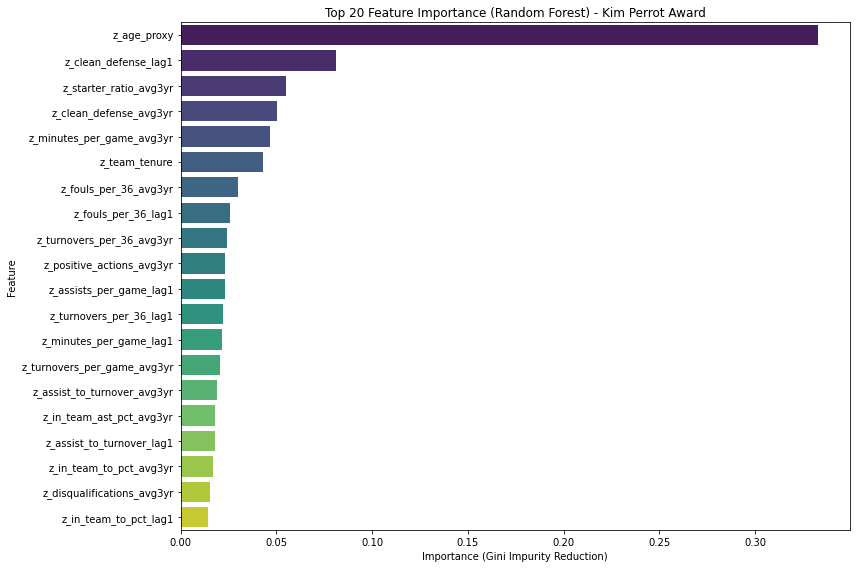


Insight: The model relied most heavily on 'z_age_proxy' (0.3327) while 'z_turnovers_per_game_lag1' contributed the least to the decision.


In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Feature Importance Analysis
# ---------------------------------------------------------
importances = final_rf.feature_importances_
feature_names = features_final_c 

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance_df.head(15).to_string(index=False))

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))

sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(20), 
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title('Top 20 Feature Importance (Random Forest) - Kim Perrot Award')
plt.xlabel('Importance (Gini Impurity Reduction)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

top_feature = feature_importance_df.iloc[0]['Feature']
top_score = feature_importance_df.iloc[0]['Importance']
bottom_feature = feature_importance_df.iloc[-1]['Feature']

print(f"\nInsight: The model relied most heavily on '{top_feature}' ({top_score:.4f}) "
      f"while '{bottom_feature}' contributed the least to the decision.")


In [ ]:
# TODO: maybe add some features (related to real predictions to KPSA), precision metrics and stuff like that
